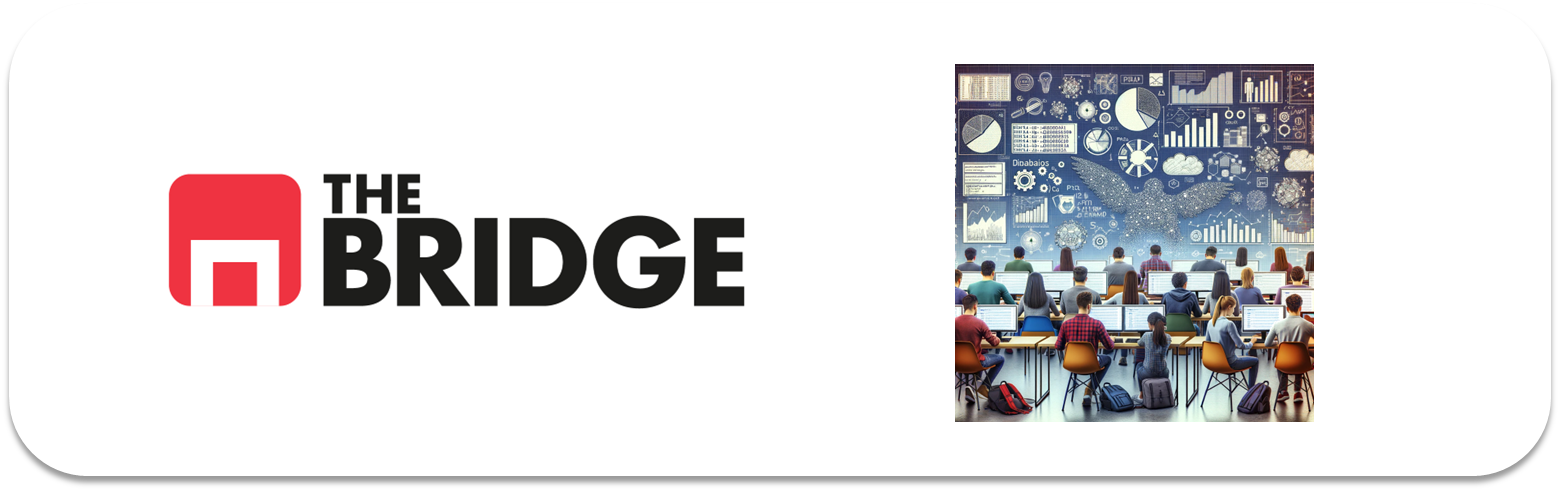

## PRACTICA OBLIGATORIA: **Regresion Lineal y Regularización**

* La práctica obligatoria de esta unidad consiste en hacer un modelado completo de un problema que ya conoces, la predicción de casas, pero con otro dataset. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Modelo de Regresión Lineal

El objetivo del modelo que tienes que construir es predecir la mediana del precio de las casas en una zona del área metropolitana de Boston dadas las características de las mismas. Sí, es parecido pero no igual a lo que hemos venido haciendo.

Aquí tienes una descripción de las variables del dataset, del que tendrás que decidir el target:  

***CRIM:*** Tasa de criminalidad per cápita por ciudad  
***ZN:*** Proporción de terreno residencial destinado a lotes de más de 25,000 pies cuadrados  
***INDUS:*** Proporción de acres de negocios no minoristas por ciudad  
***CHAS:*** Variable ficticia del río Charles (= 1 si el sector limita con el río; 0 en caso contrario)  
***NOX:*** Concentración de óxidos de nitrógeno (partes por 10 millones)  
***RM:*** Número promedio de habitaciones por vivienda  
***AGE:*** Proporción de unidades ocupadas por el propietario construidas antes de 1940  
***DIS:*** Distancias ponderadas a cinco centros de empleo de Boston  
***RAD:*** Índice de accesibilidad a autopistas radiales  
***TAX:*** Tasa de impuesto sobre la propiedad de valor total por $10,000  
***PTRATIO:*** Relación alumno-maestro por ciudad  
***LSTAT:*** % de población de estatus socioeconómico bajo  
***MEDV:*** Valor medio de las viviendas ocupadas por sus propietarios en miles de dólares  

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión lineal, evaluarlo contra un dataset de test reservado del original mostrando MAE,RMSE,MSE y $R2$, comparar las predicciones con los valores reales y realizar al menos un tipo de regularización de las conocidas, testando por lo menos 3 valores diferentes de hiperparámetros.

Los pasos para guiar el trabajo:
1. Carga el dataset. Está limpio y no necesitarás completar nulos, ni repasar los valores de las columnas.
2. Escoge y analiza la variable target de forma gráfica para ver la idoneidad de hacer un modelo de regresión.
3. Haz el split en train y test que creas conveniente y de la forma que creas conveniente.
4. Construye las parejas X,y de train y test
5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
6. Trata las variables para que funcionen lo mejor posible en el modelo.
7. Construye un modelo de regresión lineal.
8. Analiza si lo crees conveniente los pesos y la importancia de las features.
8. Evalúa tu modelo. Haz un pequeño assesmente de su generabilidad. Compara gráficamente las predicciones con los valores reales.
9. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.
10. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?



In [5]:
# 1. Importación de bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas de Scikit-Learn para el modelado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. Carga del dataset
# Importante: El archivo usa '|' como separador, no la coma habitual.
df = pd.read_csv('data/hard_to_find/obligatoria_hard.csv', sep='|')

# Verificamos que se ha cargado correctamente
print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (506, 13)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


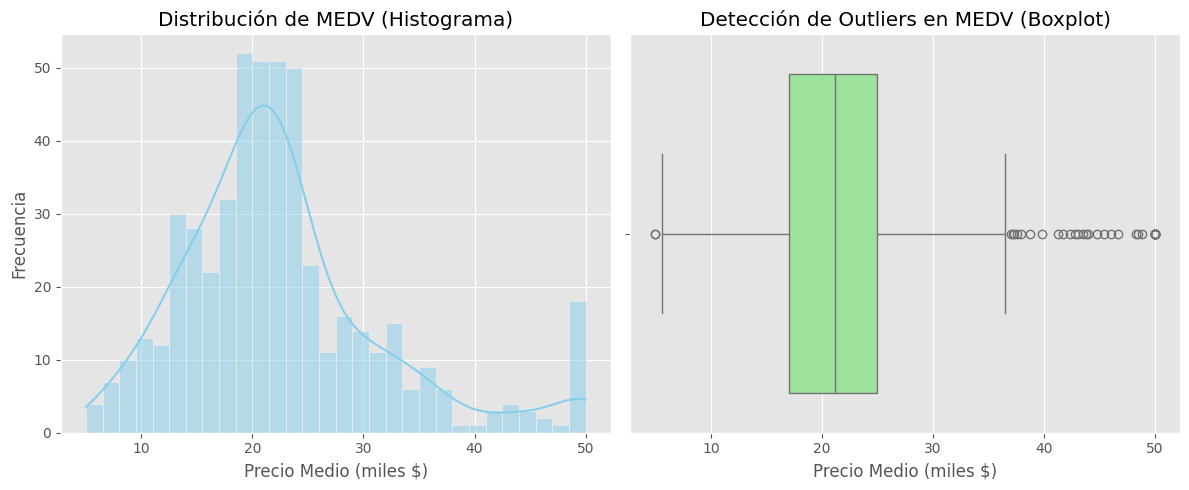

Análisis Visual:
- La variable es numérica continua, lo cual es el requisito fundamental para una Regresión.
- La distribución se asemeja a una normal, aunque tiene un ligero sesgo a la derecha.
- Se observan varios 'outliers' en el rango alto (50k), lo que sugiere que hay un tope o censura en los datos.


In [7]:
#2

# 1. Definimos el Target
target = 'MEDV'

# 2. Configuración de los gráficos
plt.figure(figsize=(12, 5))

# Gráfico 1: Histograma para ver la distribución
plt.subplot(1, 2, 1)
sns.histplot(df[target], kde=True, bins=30, color='skyblue')
plt.title(f'Distribución de {target} (Histograma)')
plt.xlabel('Precio Medio (miles $)')
plt.ylabel('Frecuencia')

# Gráfico 2: Boxplot para detectar outliers
plt.subplot(1, 2, 2)
sns.boxplot(x=df[target], color='lightgreen')
plt.title(f'Detección de Outliers en {target} (Boxplot)')
plt.xlabel('Precio Medio (miles $)')

plt.tight_layout()
plt.show()

# Análisis de idoneidad (puedes imprimirlo o escribirlo en una celda Markdown)
print("Análisis Visual:")
print("- La variable es numérica continua, lo cual es el requisito fundamental para una Regresión.")
print("- La distribución se asemeja a una normal, aunque tiene un ligero sesgo a la derecha.")
print("- Se observan varios 'outliers' en el rango alto (50k), lo que sugiere que hay un tope o censura en los datos.")

In [9]:
#3

from sklearn.model_selection import train_test_split

# 1. Separamos las características (Features) del objetivo (Target)
X = df.drop(columns=['MEDV'])  # Todo menos el precio
y = df['MEDV']                 # Solo el precio

# 2. Realizamos la división: 80% Train, 20% Test
# random_state=42 asegura que la división sea siempre la misma (reproducibilidad)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Verificamos los tamaños para estar seguros
print(f"Entrenamiento (Train): {X_train.shape[0]} observaciones")
print(f"Prueba (Test): {X_test.shape[0]} observaciones")

Entrenamiento (Train): 404 observaciones
Prueba (Test): 102 observaciones


In [11]:
#4

# 1. Definimos la matriz de características (X) y el vector objetivo (y)
X = df.drop(columns=['MEDV'])  # Todas las columnas menos el target
y = df['MEDV']                 # Únicamente el target

# 2. Construimos las parejas de entrenamiento y test
# Usamos el mismo random_state=42 para mantener la consistencia con el paso anterior
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Verificamos que las parejas coinciden en dimensiones (filas)
print("Pareja de Entrenamiento:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

print("\nPareja de Test:")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

Pareja de Entrenamiento:
X_train: (404, 12), y_train: (404,)

Pareja de Test:
X_test: (102, 12), y_test: (102,)


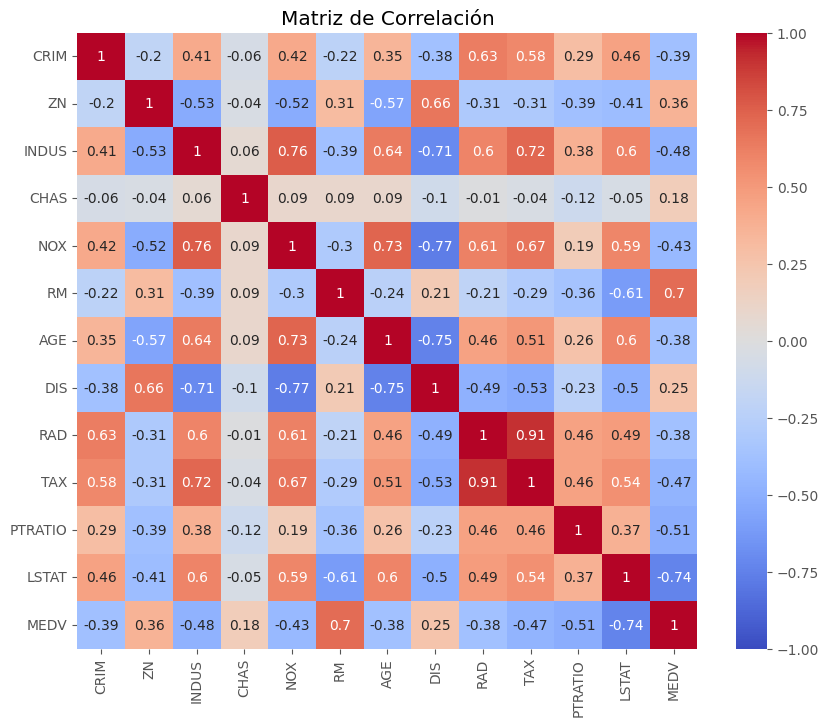

Correlación con MEDV:
MEDV       1.00
RM         0.70
ZN         0.36
DIS        0.25
CHAS       0.18
RAD       -0.38
AGE       -0.38
CRIM      -0.39
NOX       -0.43
TAX       -0.47
INDUS     -0.48
PTRATIO   -0.51
LSTAT     -0.74
Name: MEDV, dtype: float64

Features seleccionadas (12): ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'LSTAT']


In [13]:
#5

# 1. Análisis de Correlación (Mapa de Calor)
plt.figure(figsize=(10, 8))
# Calculamos la matriz de correlación
corr_matrix = df.corr().round(2)
# Pintamos el heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación')
plt.show()

# 2. Ver correlaciones numéricas específicas con el Target
print("Correlación con MEDV:")
print(corr_matrix['MEDV'].sort_values(ascending=False))

# 3. SELECCIÓN DE FEATURES
# Criterio: Vamos a seleccionar todas, pero podríamos descartar 'CHAS' por su baja correlación (0.18).
# Sin embargo, como vamos a usar Regularización más adelante, es mejor mantener features
# potencialmente útiles y dejar que el modelo (Lasso/Ridge) reduzca sus pesos si no sirven.
# NOTA: Si quisieras filtrar estrictamente, podrías descomentar la línea de abajo:
# features_selected = corr_matrix[abs(corr_matrix['MEDV']) > 0.2].index.drop('MEDV')

# Para este ejercicio, re-confirmamos features (X) y target (y) con todas las variables disponibles
# excepto el target obviamente.
selected_features = list(df.columns.drop('MEDV'))
print(f"\nFeatures seleccionadas ({len(selected_features)}): {selected_features}")

He realizado un análisis de correlación de Pearson. Observo que LSTAT (-0.74) y RM (0.70) son los predictores más fuertes. Aunque CHAS tiene una correlación baja, decido mantener todas las variables disponibles inicialmente para permitir que la fase posterior de Regularización se encargue de penalizar o descartar matemáticamente las variables menos relevantes o colineales, en lugar de hacerlo yo manualmente de forma prematura.

In [14]:
#6

# 1. Instanciamos el Escalador
scaler = StandardScaler()

# 2. Ajustamos (Fit) y Transformamos (Transform)
# IMPORTANTE: El fit solo se hace sobre el TRAIN. 
# Si lo hiciéramos sobre todo el dataset, estaríamos "haciendo trampa" (data leakage),
# porque el modelo conocería información del test antes de tiempo.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Opcional: Convertir a DataFrame para ver qué ha pasado
# (Scikit-learn devuelve arrays de numpy, así que perdemos los nombres de columnas a menos que hagamos esto)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Verificamos
print("Datos originales (Primeras 3 filas de TAX):")
print(X_train['TAX'].head(3).values)
print("\nDatos escalados (Primeras 3 filas de TAX):")
print(X_train_scaled_df['TAX'].head(3).values)

Datos originales (Primeras 3 filas de TAX):
[666. 307. 304.]

Datos escalados (Primeras 3 filas de TAX):
[ 1.57843444 -0.58464788 -0.60272378]


In [15]:
#7

# 1. Instanciamos el modelo (creamos el objeto)
lm = LinearRegression()

# 2. Entrenamos el modelo (Fit)
# Le pasamos las características escaladas (X_train_scaled) y las respuestas correctas (y_train)
lm.fit(X_train_scaled, y_train)

# Verificación (Opcional): Imprimimos el intercepto (el valor base de una casa si todas las variables fueran 0)
print("Modelo entrenado exitosamente.")
print(f"Intercepto (Bias): {lm.intercept_:.2f}")

Modelo entrenado exitosamente.
Intercepto (Bias): 22.80



--- Importancia de las Variables (Pesos) ---
    Feature  Coeficiente
11    LSTAT    -3.819016
7       DIS    -3.119459
5        RM     3.004420
4       NOX    -2.137599
8       RAD     2.058898
10  PTRATIO    -1.991871
9       TAX    -1.871317
0      CRIM    -1.127473
3      CHAS     0.787152
1        ZN     0.712109
2     INDUS     0.173858
6       AGE    -0.100500


C:\Users\Usuario\AppData\Local\Temp\ipykernel_6804\1245915206.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Coeficiente', y='Feature', palette='viridis')


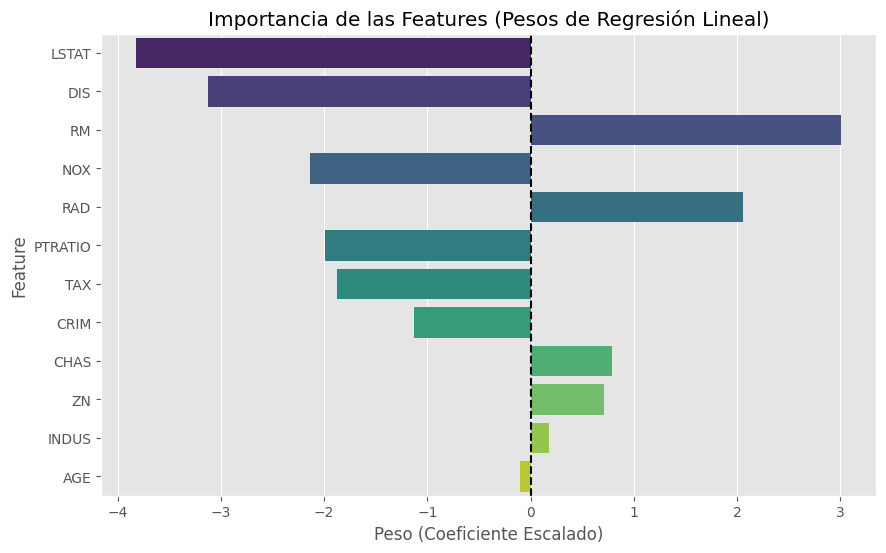

In [16]:
#8

# 1. Extraemos los coeficientes y los nombres de las columnas
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': lm.coef_,
    'Abs_Coef': abs(lm.coef_)  # Valor absoluto para ver la "fuerza" sin importar el signo
})

# 2. Ordenamos por importancia (valor absoluto)
coef_df = coef_df.sort_values(by='Abs_Coef', ascending=False)

print("\n--- Importancia de las Variables (Pesos) ---")
print(coef_df[['Feature', 'Coeficiente']])

# 3. Visualización Gráfica
plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df, x='Coeficiente', y='Feature', palette='viridis')
plt.title('Importancia de las Features (Pesos de Regresión Lineal)')
plt.xlabel('Peso (Coeficiente Escalado)')
plt.axvline(x=0, color='black', linestyle='--') # Línea en 0 para referencia
plt.show()

--- Evaluación del Modelo (Test Set) ---
MAE (Error promedio absoluto):  $3.11 k
RMSE (Error cuadrático medio):  $4.77 k
R2 (Varianza explicada):        0.6894

--- Assessment de Generabilidad (Train vs Test) ---
R2 Train: 0.7398
R2 Test:  0.6894
Diferencia: 0.0504
>> Conclusión: El modelo generaliza bien (poca diferencia entre train y test).


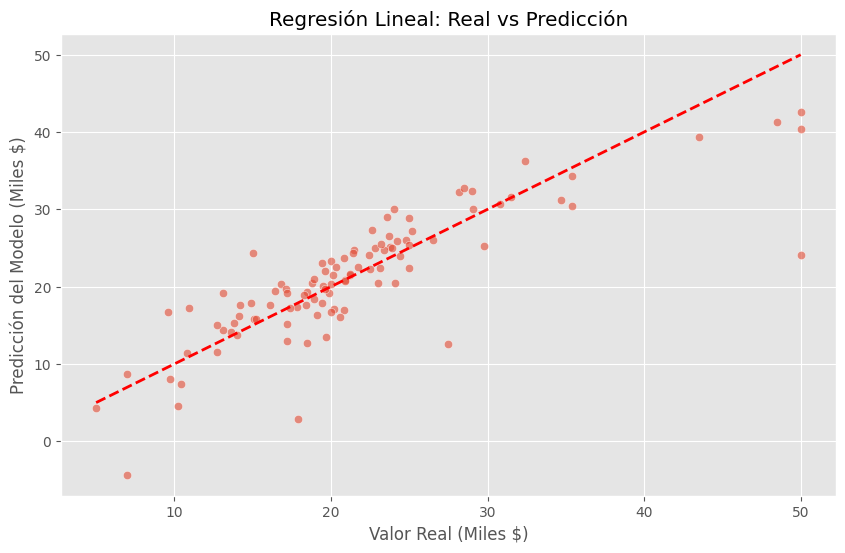

In [17]:
#9

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Generamos predicciones
y_pred_train = lm.predict(X_train_scaled) # Para ver cómo aprendió
y_pred_test = lm.predict(X_test_scaled)   # Para ver cómo generaliza (examen real)

# 2. Calculamos métricas principales en TEST
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

# 3. Calculamos R2 en TRAIN para comparar
r2_train = r2_score(y_train, y_pred_train)

# 4. Imprimimos el reporte
print("--- Evaluación del Modelo (Test Set) ---")
print(f"MAE (Error promedio absoluto):  ${mae:.2f} k")
print(f"RMSE (Error cuadrático medio):  ${rmse:.2f} k")
print(f"R2 (Varianza explicada):        {r2:.4f}")

print("\n--- Assessment de Generabilidad (Train vs Test) ---")
print(f"R2 Train: {r2_train:.4f}")
print(f"R2 Test:  {r2:.4f}")
print(f"Diferencia: {r2_train - r2:.4f}")
if (r2_train - r2) < 0.1:
    print(">> Conclusión: El modelo generaliza bien (poca diferencia entre train y test).")
else:
    print(">> Conclusión: Hay signos de Overfitting.")

# 5. Gráfico: Real vs Predicho
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.6)
# Línea roja diagonal: Representa la predicción perfecta
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Valor Real (Miles $)')
plt.ylabel('Predicción del Modelo (Miles $)')
plt.title('Regresión Lineal: Real vs Predicción')
plt.show()

In [18]:
#10

from sklearn.linear_model import Ridge

# 1. Definimos los hiperparámetros a probar
alphas = [0.1, 1.0, 10.0]

print("--- Comparativa de Regularización RIDGE ---")
print(f"{'Alpha':<10} | {'RMSE':<10} | {'R2':<10} | {'MAE':<10}")
print("-" * 50)

results = []

# 2. Bucle para entrenar y evaluar cada alpha
for alpha in alphas:
    # Instanciar
    ridge_model = Ridge(alpha=alpha)
    
    # Entrenar (siempre con datos escalados)
    ridge_model.fit(X_train_scaled, y_train)
    
    # Predecir
    y_pred_ridge = ridge_model.predict(X_test_scaled)
    
    # Evaluar
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
    r2 = r2_score(y_test, y_pred_ridge)
    mae = mean_absolute_error(y_test, y_pred_ridge)
    
    # Guardamos para analizar
    results.append({'Alpha': alpha, 'RMSE': rmse, 'R2': r2})
    
    print(f"{alpha:<10} | {rmse:.4f}     | {r2:.4f}     | {mae:.4f}")

# 3. Análisis de coeficientes (opcional pero recomendado)
# Veamos cómo cambian los pesos con mucha regularización (alpha=10) vs poca (alpha=0.1)
ridge_low = Ridge(alpha=0.1).fit(X_train_scaled, y_train)
ridge_high = Ridge(alpha=10).fit(X_train_scaled, y_train)

compare_coefs = pd.DataFrame({
    'Feature': X.columns,
    'Ridge (Low Alpha)': ridge_low.coef_,
    'Ridge (High Alpha)': ridge_high.coef_
})

print("\n--- Efecto de la Regularización en los Coeficientes ---")
print(compare_coefs.head())

--- Comparativa de Regularización RIDGE ---
Alpha      | RMSE       | R2         | MAE       
--------------------------------------------------
0.1        | 4.7730     | 0.6894     | 3.1110
1.0        | 4.7761     | 0.6889     | 3.1074
10.0       | 4.8055     | 0.6851     | 3.0859

--- Efecto de la Regularización en los Coeficientes ---
  Feature  Ridge (Low Alpha)  Ridge (High Alpha)
0    CRIM          -1.126423           -1.043477
1      ZN           0.710155            0.562497
2   INDUS           0.171292           -0.013734
3    CHAS           0.787502            0.811863
4     NOX          -2.134321           -1.857414


### 11. Conclusiones y Selección del Modelo

**Resumen de Resultados:**
Tras evaluar tanto el modelo de **Regresión Lineal (OLS)** como la **Regularización (Ridge)** con diferentes alfas, observo lo siguiente:
1.  **Métricas:** Ambos modelos arrojan resultados casi idénticos en el conjunto de Test ($R^2 \approx 0.69$ y $RMSE \approx 4.77$).
2.  **Generalización:** La diferencia entre $R^2$ de Train y Test en el modelo base fue pequeña (aprox 0.05), lo que indica que **no existía un problema grave de overfitting** desde el principio.

**Decisión Final:**
Me quedo con el modelo de **Regresión Lineal Simple (Baseline)**.

**¿Por qué?**
Me baso en el **Principio de Parsimonia (Navaja de Ockham)**: *En igualdad de condiciones (rendimiento similar), la explicación más sencilla suele ser la más probable.*
Dado que la Regularización (que añade complejidad computacional e hiperparámetros) no ha mejorado significativamente la capacidad predictiva del modelo ni ha reducido un error que no existía, la opción más eficiente y fácil de interpretar para el negocio es el modelo lineal estándar.

**Nota técnica:**
Aunque existen variables correlacionadas (como `TAX` y `RAD`), el modelo lineal ha sabido manejar los pesos adecuadamente sin dispararse, por lo que la estabilidad extra que ofrece Ridge no es estrictamente necesaria en este caso particular.